# Modelo: Random

In [13]:
import os, random
import pandas as pd
import sys; sys.path.append('..')
from src.evaluation import temporal_train_test_split, evaluate_model

MODEL_NAME = 'random'
RESULTS_DIR = f'../results/{MODEL_NAME}'

## Definición del modelo

In [14]:
class RandomRecommender:
    def __init__(self, seed=42):
        self._rng = random.Random(seed)
        self._all_items = []

    def fit(self, train_reviews):
        self._all_items = train_reviews['business_id'].unique().tolist()
        return self

    def recommend(self, user_id, train_reviews, top_k=10):
        seen = set(train_reviews[train_reviews['user_id'] == user_id]['business_id'])
        candidates = [i for i in self._all_items if i not in seen]
        k = min(top_k, len(candidates))
        return self._rng.sample(candidates, k) if k > 0 else []

## Datos

In [15]:
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)
print(f'Train: {len(train_reviews)} | Test: {len(test_reviews)}')

Train: 61870 reviews | Test: 13114 reviews
Train: 61870 | Test: 13114


## Entrenamiento y evaluación

In [16]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

model = RandomRecommender(seed=42).fit(train_reviews)

metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews, train_reviews, k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print(metrics.round(4))

    precision  recall    ndcg  novelty  hit_rate  coverage     ild
K                                                                 
5      0.0031  0.0087  0.0058   7.0050    0.0152       1.0  0.5413
10     0.0033  0.0172  0.0089   7.0200    0.0320       1.0  0.5430
20     0.0032  0.0331  0.0134   7.0251    0.0610       1.0  0.5427


## Guardar resultados

In [17]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f'{RESULTS_DIR}/metrics.csv')
print(f'Saved -> results/{MODEL_NAME}/metrics.csv')

Saved -> results/random/metrics.csv


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['lo9Z0oVT-kz2DJwPE3X0Og', 'R53y0qIWqJZxnbyWNDbrMg', 'dzAZWHtJ52JI8J4zB2mkow', '4tqv48yYK6Jk5aZsncDC-g', 'QlueMJlhDGDGxR9arq_xSg']

Usuario lo9Z0oVT-kz2DJwPE3X0Og  |  5 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] City Diner - "Finally a new diner in the city MUCH NEEDED for industry people & socialites that have late night schedules . Very Clean and mangled very well"
  [5*] National Mechanics - "Place is great but the evening server Jennifer makes it amazing. Most personable & welcoming server I've ever met. Make sure you guys keep her around P.S. the l..."
  [4*] Fare - "Good food pretty good variety menu . My favorite thing about this place is their outdoor courtyard which is very nice at night w/ the heated lamps & fireplace i..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Carmen's Famous Italian Hoagies (Philadelphia) - 3

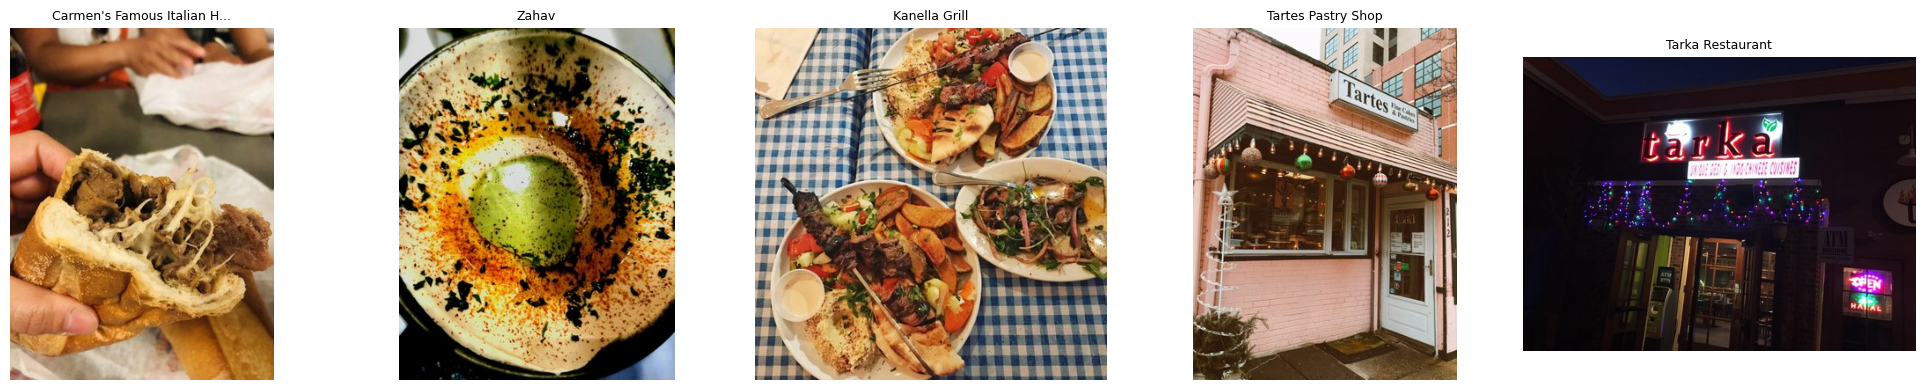


Usuario R53y0qIWqJZxnbyWNDbrMg  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Han Dynasty - "First, I must rave about the superb service we received by our waitress. We came here last Sunday after making reservations for 15 for my boyfriend's surprise b..."
  [4*] Crazy Sushi - "One item is enough to make me write this review:  Salmon Pizza! Get it! Pictures & a more thorough review to come when I return - which shall be soon."
  [4*] Moshulu - "This review is for their restaurant week menu  Food: 3.5/5  Apps: california shrimp crunch roll & crispy calamari/artichoke hearts Their appetizers were amazing..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Campo's Philly Cheesesteaks (Philadelphia) - 3.5* - Food, Local Flavor, Sandwiches, Restaurants, Fast Food, Deli...
  2. Cafe Square One (Philadelphia) - 4.5* - Food, Coffee & Tea, Cafes, Salad, Sa

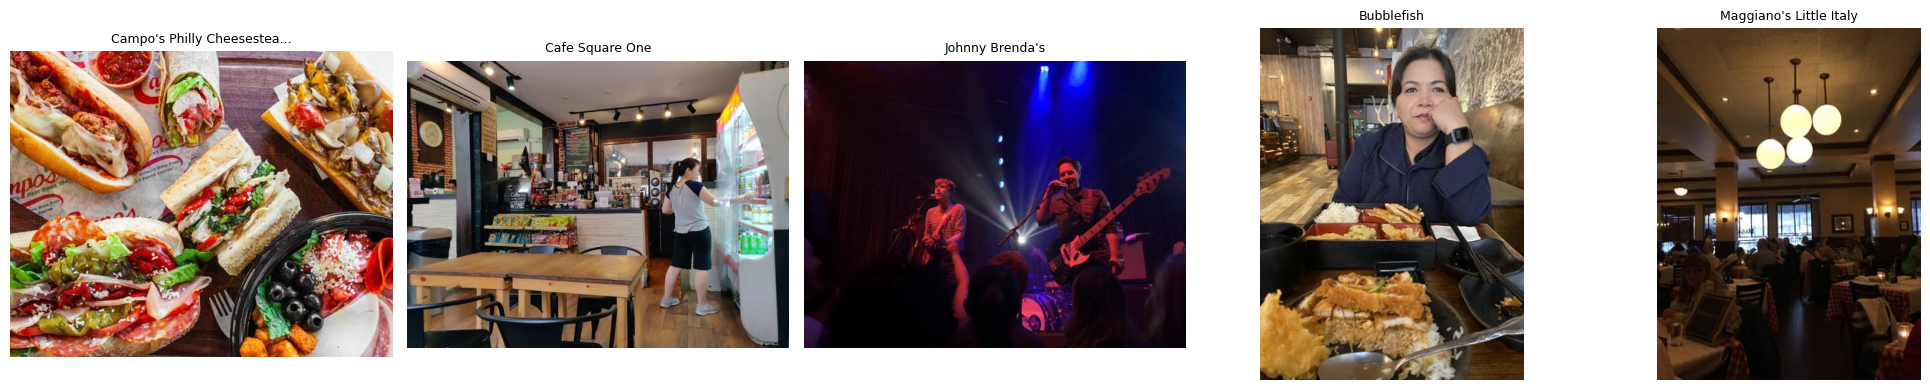


Usuario dzAZWHtJ52JI8J4zB2mkow  |  5 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Dalessandro’s Steaks & Hoagies - "And down simply the best cheesesteak in Philadelphia and make sure you go a little early because it's always packed door-to-door for lunch"
  [3*] Jim's South St - "Very tasty but they need to add more meat for 9$ cheesesteak  Their are a few better out there Delsandros and sonnys right up the street  Fries are not availabl..."
  [1*] John's Roast Pork - "Simply the most OVER RATED pork sandwich I've ever had...  Their cheese steaks are the highlight of this place!!!! Their prices are about par for the course"
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. The Blue Duck (Philadelphia) - 4.0* - Restaurants, American (New), Burgers, Breakfast & Brunch, Sa...
  2. Kisso Sushi (Philadelphia) - 4.0* - Sushi Bars, Restaurants
  3. Hawthornes B

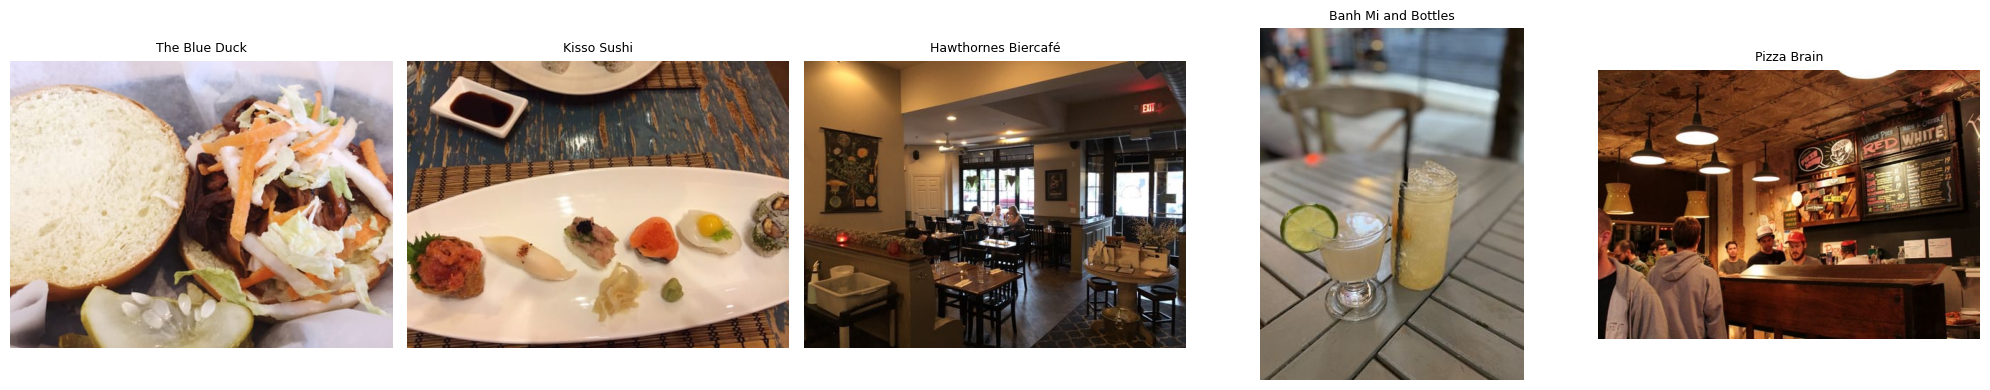


Usuario 4tqv48yYK6Jk5aZsncDC-g  |  20 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Tinto - "This place is one of those that you might not want to miss it if you live in Philadelphia. I went there last November and had an amazing time. The atmosphere in..."
  [5*] P S & Co - "Thumbs up to the owner for her brilliant ideas. Pure Sweet is a place that I truly feel I'm not waisting my money. I pursue a very restricted diet and the fact ..."
  [5*] The Farm and Fisherman - "What can I say about this place? It's a gem. I had dinner here couple of months ago leaving me with the best impressions. Service is outstanding. The server pre..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Spirit of Philadelphia (Philadelphia) - 3.0* - Event Planning & Services, American (New), Venues & Event Sp...
  2. Sweet Lucy's Smokehouse (Philadelphia) - 4.5* - Smokehouse, B

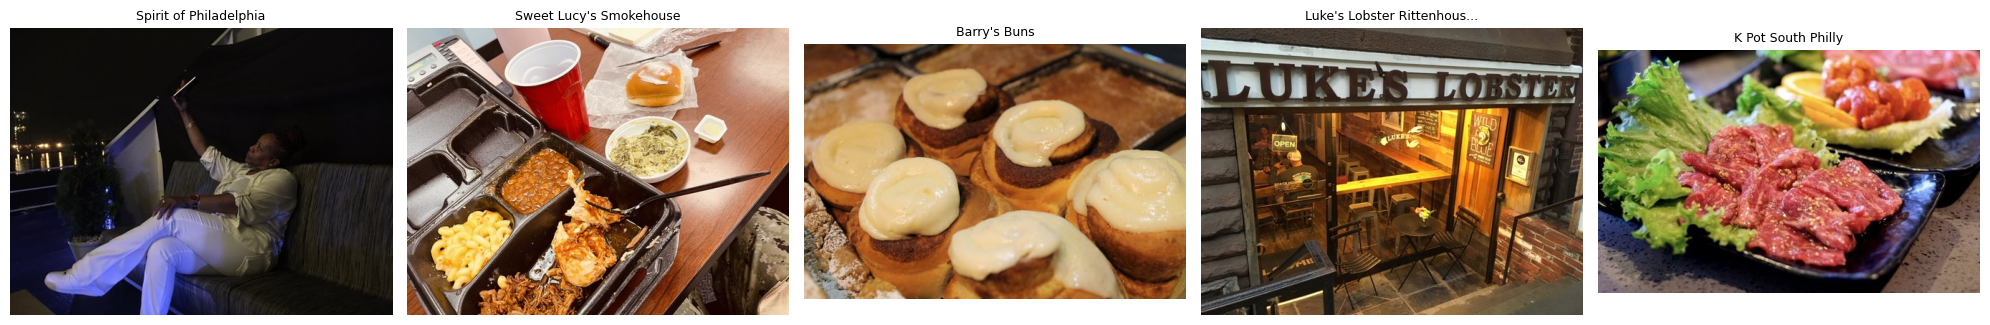


Usuario QlueMJlhDGDGxR9arq_xSg  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Pizzeria Vetri - "The arugula salad with pesto was hands down the best salad I've had in my life. And if you're even considering the Nutella dessert pie, get it. You won't be dis..."
  [5*] Dante & Luigi's - "Dante & Luigi's was the perfect place for my boyfriend and I to take his mom when she visited town. The atmosphere was great - felt just like you were in someon..."
  [5*] Kanella South - "The portions are large, the food is authentic, the new location is gorgeous, and the whole experience is amazing. I absolutely adore Kenella's!"
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Las Bugambilias (Philadelphia) - 4.0* - Restaurants, Mexican
  2. Fogo de Chao (Philadelphia) - 4.0* - Seafood, Steakhouses, Brazilian, Restaurants
  3. Saigon Maxim Restaurant (Philadelphia)

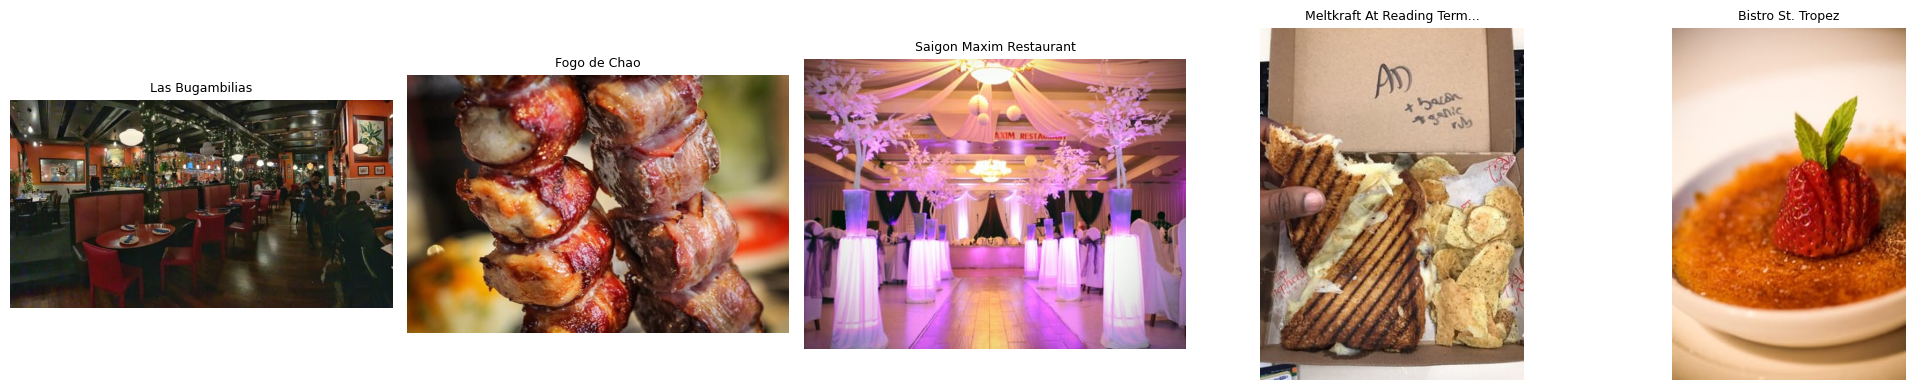

In [18]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )